In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

EQ = pd.read_csv(r"C:\Users\tapas\Downloads\query.csv")
EQ.head(2)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-24T04:09:47.901Z,12.6319,92.7492,35.000,4.8,mb,46.0,64,6.440,1.07,...,2026-04-01T22:48:00.040Z,"103 km N of Bamboo Flat, India",earthquake,12.10,1.911,0.087,41,reviewed,us,us
1,2025-10-16T22:10:23.971Z,13.3577,92.5564,15.163,5.0,mb,89.0,65,4.921,0.85,...,2026-01-09T15:38:38.040Z,"184 km N of Bamboo Flat, India",earthquake,9.59,4.409,0.056,105,reviewed,us,us


In [33]:
#grouping by time
yr =EQ.groupby('time')
print(yr)

In [34]:
#compute annual time

yr.size()

time
2016-09-04T22:28:38.650Z    1
2016-09-16T05:18:49.780Z    1
2016-09-20T09:10:11.230Z    1
2016-11-25T11:17:10.660Z    1
2016-12-27T10:50:19.090Z    1
                           ..
2025-07-21T18:00:56.801Z    1
2025-08-10T06:32:32.923Z    1
2025-10-04T20:31:03.053Z    1
2025-10-16T22:10:23.971Z    1
2025-12-24T04:09:47.901Z    1
Length: 82, dtype: int64

In [42]:
#compute mean magnitude 

magnitue=EQ['mag']
magnitue.mean()


np.float64(4.558536585365853)

In [43]:
#compute max magnitude
magnitue.max()

np.float64(5.2)

Text(0.5, 1.0, 'Rolling 12 Month Mean Magnitude')

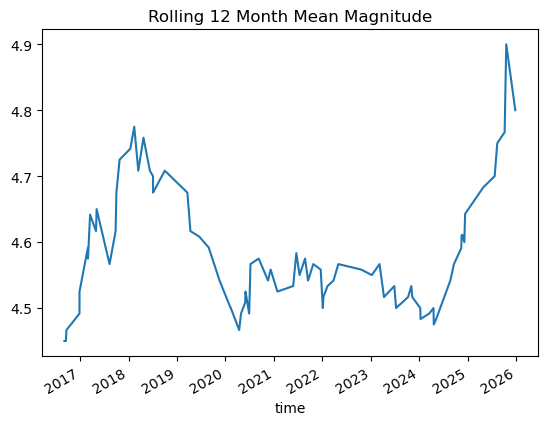

In [61]:
#make a rolling 12 month mean plot
from datetime import time
EQ["time"] = pd.to_datetime(EQ["time"])
EQ["time"].sort_values(ascending=False)
EQ["Rolling_12_Month_Mean"] = (EQ["mag"] .rolling(window=12, min_periods=1).mean())
EQ.set_index('time')['Rolling_12_Month_Mean'].sort_index().plot().set_title("Rolling 12 Month Mean Magnitude")


In [30]:
import pandas as pd
import numpy as np
from pathlib import Path

movies = pd.read_csv (Path('C:/Users/tapas/Downloads/imdb-top-1000 (1).csv'))
movies.head()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0


In [26]:
#find the genre having highes imdb rating
genres = movies.groupby('Genre')
genres['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

Genre
Western    8.35
Name: IMDB_Rating, dtype: float64

In [29]:
#find the director with highest popularity
director = movies.groupby('Director')
director['No_of_Votes'].sum().sort_values(ascending=False).head(1)

Director
Christopher Nolan    11578345
Name: No_of_Votes, dtype: int64

In [38]:
#find the highest rated movie of each genre
genres = movies.groupby('Genre')
movies.loc[genres['IMDB_Rating'].idxmax(), ['Genre', 'Series_Title', 'IMDB_Rating']].sort_values('IMDB_Rating', ascending=False).head(1)

,Genre,Series_Title,IMDB_Rating
0,Drama,The Shawshank Redemption,9.3


In [ ]:
#find no of movies done by each actor
movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False).head()

Star1
Tom Hanks          12
Robert De Niro     11
Clint Eastwood     10
Al Pacino          10
Humphrey Bogart     9
Name: Series_Title, dtype: int64

In [1]:
#merge / concatenate two dataframes
import pandas as pd
import numpy as np
from pathlib import Path

course = pd.read_csv(r"C:\Users\tapas\Downloads\courses.csv")
students = pd.read_csv(r"C:\Users\tapas\Downloads\students.csv")
deliveries = pd.read_csv(r"C:\Users\tapas\Downloads\deliveries.csv")
matches = pd.read_csv(r"C:\Users\tapas\Downloads\matches.csv")
nov = pd.read_csv(r"C:\Users\tapas\Downloads\reg-month1.csv")
students = pd.read_csv(r"C:\Users\tapas\Downloads\students.csv")
dec = pd.read_csv(r"C:\Users\tapas\Downloads\reg-month2.csv")

In [2]:
course.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
